# Notebook 02 - Demo della pipeline di preprocessing

## Scopo del notebook

Visualizziamo l'effetto delle 6 funzioni principali di
`src/preprocessing.py` su 3 slice CT campione (2 COVID + 1 non-COVID). E'
un notebook **didattico e di documentazione**: serve a:

1. Mostrare visivamente cosa fa ciascuna funzione di preprocessing.
2. Generare le figure `docs/figures/demo_0?_*.png` usate nel report.
3. Permettere debugging visivo della pipeline (utile quando si modifica
   la mask o il CLAHE).

## Pipeline visualizzata

    load_image -> resize_with_padding -> apply_clahe -> lung_mask ->
    apply_lung_mask -> build_three_channel

## Prerequisito

Esecuzione precedente di `scripts/prepare_data.py` (per avere il CSV di
training da cui campionare).


## Setup: import e selezione dei sample

In [1]:
from pathlib import Path
import sys
# Aggiungiamo la root del progetto al path cosi' che `import src.*` funzioni
# anche se il notebook viene lanciato da `notebooks/`.
sys.path.insert(0, str(Path('..').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Importiamo TUTTE le 6 funzioni che vogliamo visualizzare.
from src.preprocessing import (
    load_image, resize_with_padding, apply_clahe,
    lung_mask, apply_lung_mask, build_three_channel,
)

ROOT = Path('..')
df = pd.read_csv(ROOT / 'data/processed/train.csv')

# Selezione di 3 immagini per la demo: 2 COVID + 1 non-COVID per varieta'.
# `random_state=42` per riproducibilita' (otterrai sempre gli stessi sample).
samples = pd.concat([
    df[df.label == 'covid'].sample(2, random_state=42),
    df[df.label == 'non-covid'].sample(1, random_state=42),
], ignore_index=True)

# Carichiamo tutte le immagini in memoria una volta sola.
images_raw = [load_image(ROOT / row.filepath) for _, row in samples.iterrows()]
sample_titles = [
    f"{row.label.upper()} {i+1}  ({img.shape[0]}x{img.shape[1]})"
    for i, ((_, row), img) in enumerate(zip(samples.iterrows(), images_raw))
]

# Normalizzazione a grayscale (gestisce il caso di PNG RGB) - usata da
# tutti gli step successivi.
import cv2
images_gray = [
    img if img.ndim == 2 else cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    for img in images_raw
]

print('Loaded samples:')
for t, img in zip(sample_titles, images_raw):
    print(f'  {t}')


c:\Users\zucco\OneDrive\Desktop\progetto cv\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded samples:
  COVID 1  (254x390)
  COVID 2  (244x269)
  NON-COVID 3  (157x250)


## 1. `load_image` - immagini originali

Mostriamo i PNG cosi' come sono nel dataset: dimensioni e risoluzioni
sono eterogenee (come abbiamo visto nell'EDA).


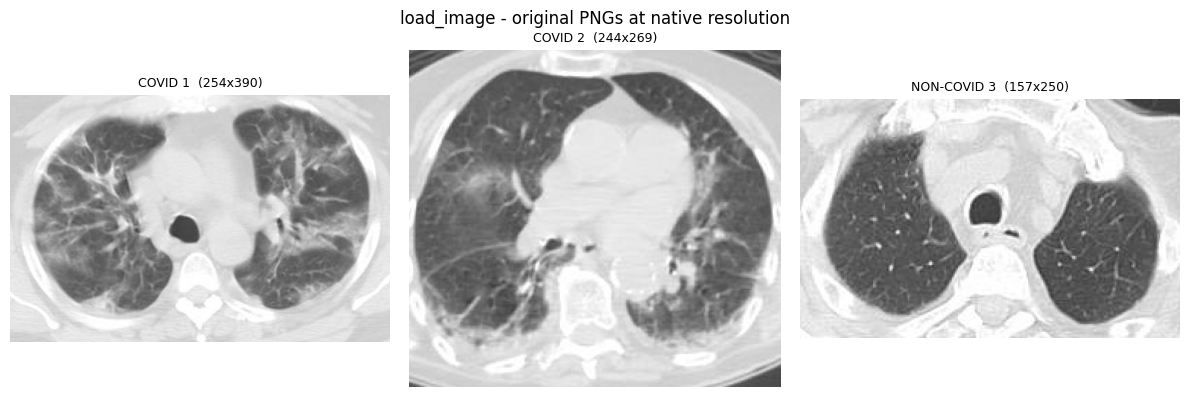

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, img, title in zip(axes, images_raw, sample_titles):
    # `cmap='gray'` per visualizzare correttamente i grayscale.
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=9)
    ax.axis('off')
fig.suptitle('load_image - original PNGs at native resolution')
plt.tight_layout()
plt.savefig(ROOT / 'docs/figures/demo_01_load.png', dpi=120, bbox_inches='tight')
plt.show()


## 2. `resize_with_padding` - resize a 224x224 con padding nero

Confronto Before/After. Notare:
- L'aspect ratio originale e' preservato (no distorsione).
- Le immagini non quadrate hanno bande nere ai bordi (padding).
- 224 e' la dimensione standard per EfficientNet-B0.


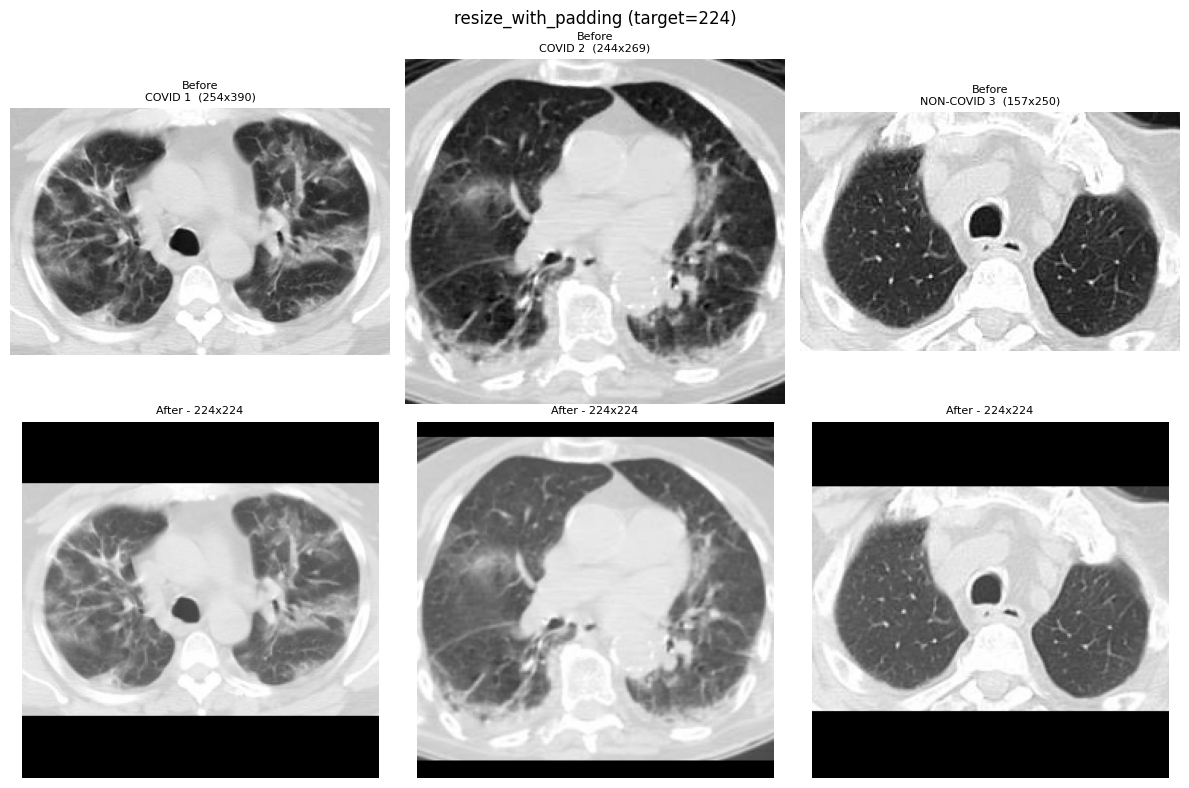

In [3]:
resized = [resize_with_padding(img, target=224) for img in images_gray]

# Layout 2x3: prima riga "before", seconda riga "after".
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for col, (orig, res, title) in enumerate(zip(images_gray, resized, sample_titles)):
    axes[0, col].imshow(orig, cmap='gray')
    axes[0, col].set_title(f'Before\n{title}', fontsize=8)
    axes[0, col].axis('off')
    axes[1, col].imshow(res, cmap='gray')
    axes[1, col].set_title(f'After - 224x224', fontsize=8)
    axes[1, col].axis('off')
fig.suptitle('resize_with_padding (target=224)')
plt.tight_layout()
plt.savefig(ROOT / 'docs/figures/demo_02_resize.png', dpi=120, bbox_inches='tight')
plt.show()


## 3. `apply_clahe` - equalizzazione adattiva (clip 2.0 e 4.0)

Mostriamo originale + due valori di `clip_limit`:
- `clip=2.0`: contrasto migliorato in modo "soft", standard.
- `clip=4.0`: contrasto piu' aggressivo, amplifica anche rumore.

Entrambi i valori finiscono come canali 1 e 2 di `build_three_channel`.


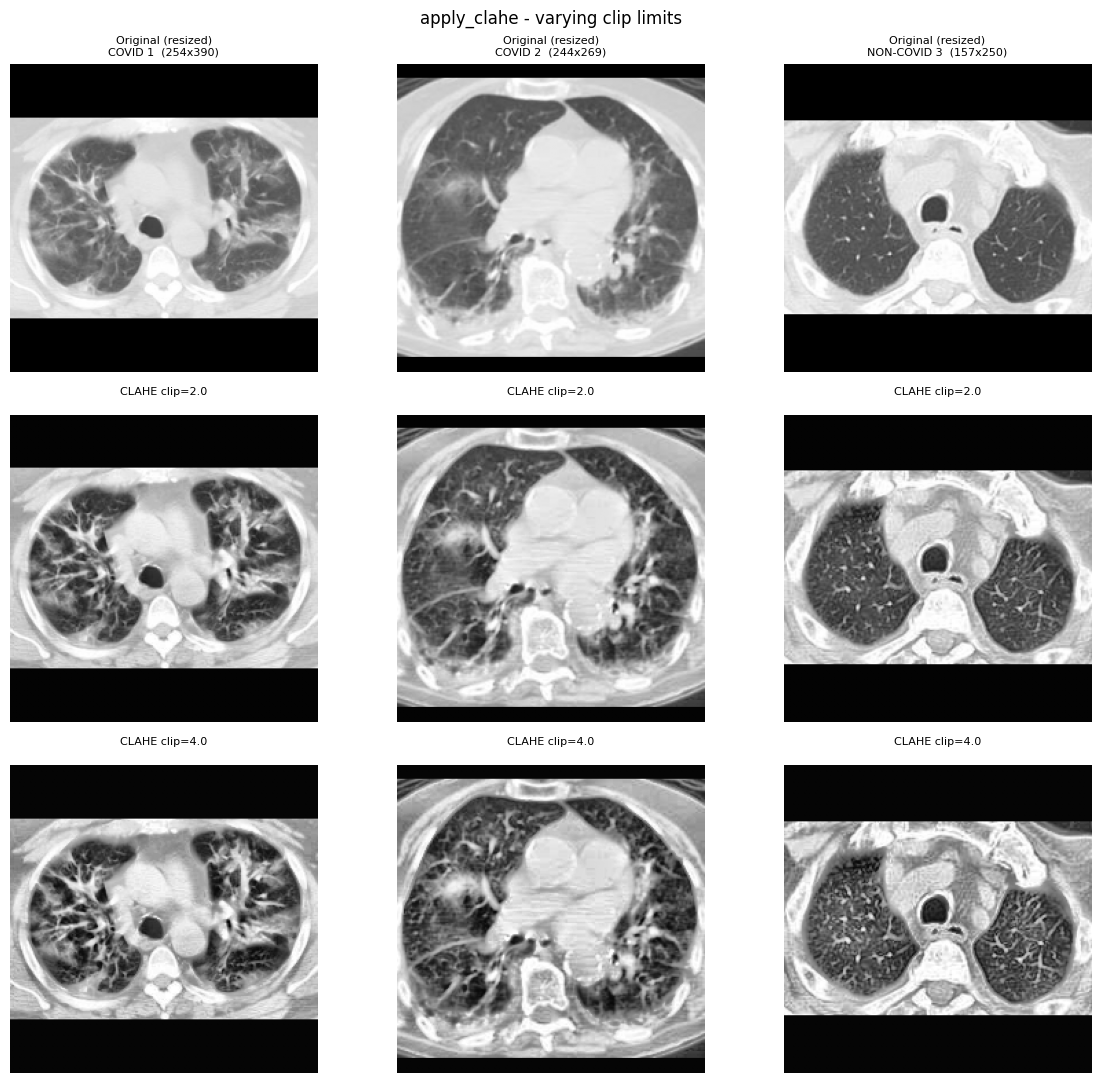

In [4]:
# Due varianti del CLAHE: clip 2.0 (canale 1) e clip 4.0 (canale 2).
clahe2 = [apply_clahe(img, clip_limit=2.0) for img in resized]
clahe4 = [apply_clahe(img, clip_limit=4.0) for img in resized]

# Layout 3x3: 3 step (orig + 2 CLAHE) x 3 sample.
fig, axes = plt.subplots(3, 3, figsize=(12, 11))
row_labels = ['Original (resized)', 'CLAHE clip=2.0', 'CLAHE clip=4.0']
for col, (orig, c2, c4, title) in enumerate(zip(resized, clahe2, clahe4, sample_titles)):
    for row, (img, row_lbl) in enumerate(zip([orig, c2, c4], row_labels)):
        # `vmin=0, vmax=255`: fissiamo i bound per confronto visivo equo
        # fra immagini diverse (senza, matplotlib auto-scaleerebbe).
        axes[row, col].imshow(img, cmap='gray', vmin=0, vmax=255)
        axes[row, col].set_title(f'{row_lbl}\n{title if row == 0 else ""}', fontsize=8)
        axes[row, col].axis('off')
fig.suptitle('apply_clahe - varying clip limits')
plt.tight_layout()
plt.savefig(ROOT / 'docs/figures/demo_03_clahe.png', dpi=120, bbox_inches='tight')
plt.show()


## 4. `lung_mask` - segmentazione polmonare

Usa la U-Net `lungmask` se installata, altrimenti il fallback classico
Otsu + morfologia. Visualizziamo la maschera come overlay rosso
semi-trasparente sull'immagine originale.

Le aree rosse sono quelle che la rete classificera' (lo sfondo viene
azzerato nello step successivo).


2026-05-16 07:48:28,710 WARNING src.preprocessing: lungmask inference failed (Python integer 600 out of bounds for uint8); using Otsu fallback
2026-05-16 07:48:28,873 WARNING src.preprocessing: lungmask inference failed (Python integer 600 out of bounds for uint8); using Otsu fallback
2026-05-16 07:48:29,024 WARNING src.preprocessing: lungmask inference failed (Python integer 600 out of bounds for uint8); using Otsu fallback


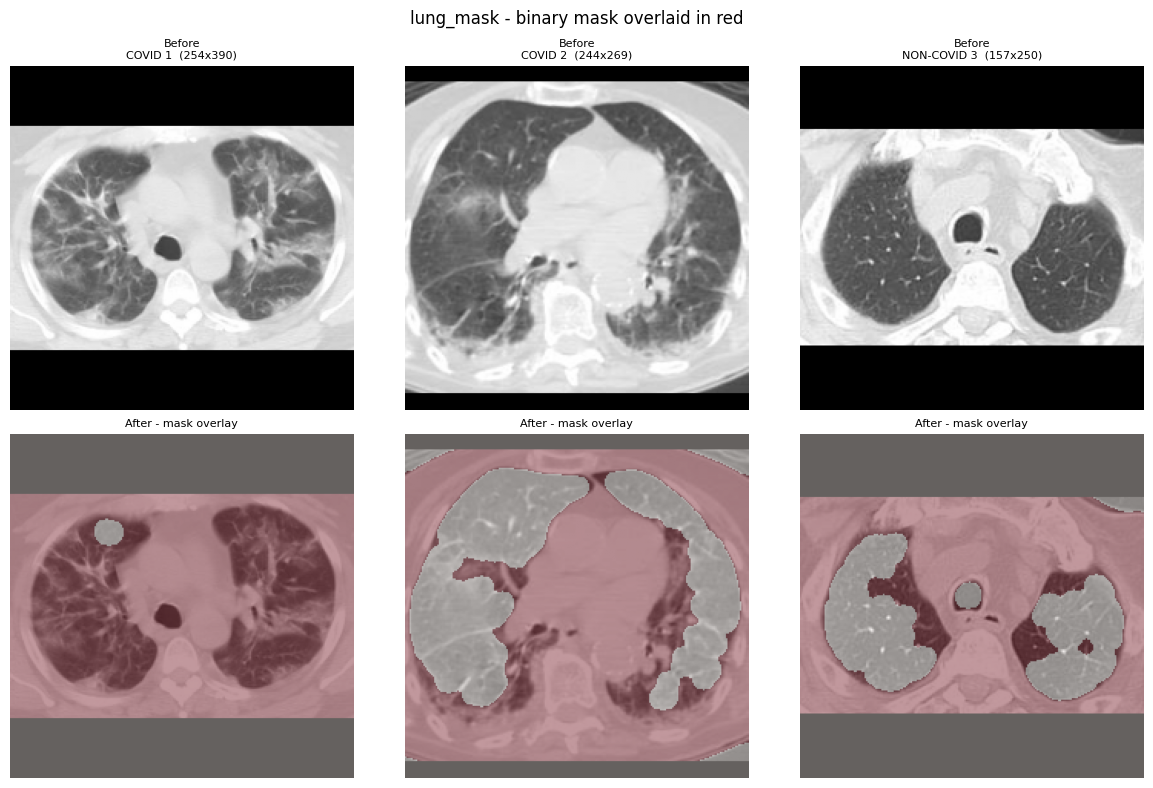

In [5]:
masks = [lung_mask(img) for img in resized]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for col, (orig, msk, title) in enumerate(zip(resized, masks, sample_titles)):
    axes[0, col].imshow(orig, cmap='gray')
    axes[0, col].set_title(f'Before\n{title}', fontsize=8)
    axes[0, col].axis('off')
    # Overlay: prima l'immagine grayscale, sopra la maschera in rosso
    # con `alpha=0.4` (semi-trasparente). Cmap 'Reds' rende le aree
    # mascherate rosse e lo sfondo trasparente.
    axes[1, col].imshow(orig, cmap='gray')
    axes[1, col].imshow(msk, cmap='Reds', alpha=0.4, vmin=0, vmax=255)
    axes[1, col].set_title('After - mask overlay', fontsize=8)
    axes[1, col].axis('off')
fig.suptitle('lung_mask - binary mask overlaid in red')
plt.tight_layout()
plt.savefig(ROOT / 'docs/figures/demo_04_lungmask.png', dpi=120, bbox_inches='tight')
plt.show()


## 5. `apply_lung_mask` - azzeramento dello sfondo

Applica la maschera dello step precedente: tutti i pixel "fuori dai
polmoni" vengono settati a 0 (nero). Questo previene che il modello
impari shortcut basati su artefatti di sfondo (scritte, barre laterali,
forme della scatola toracica).


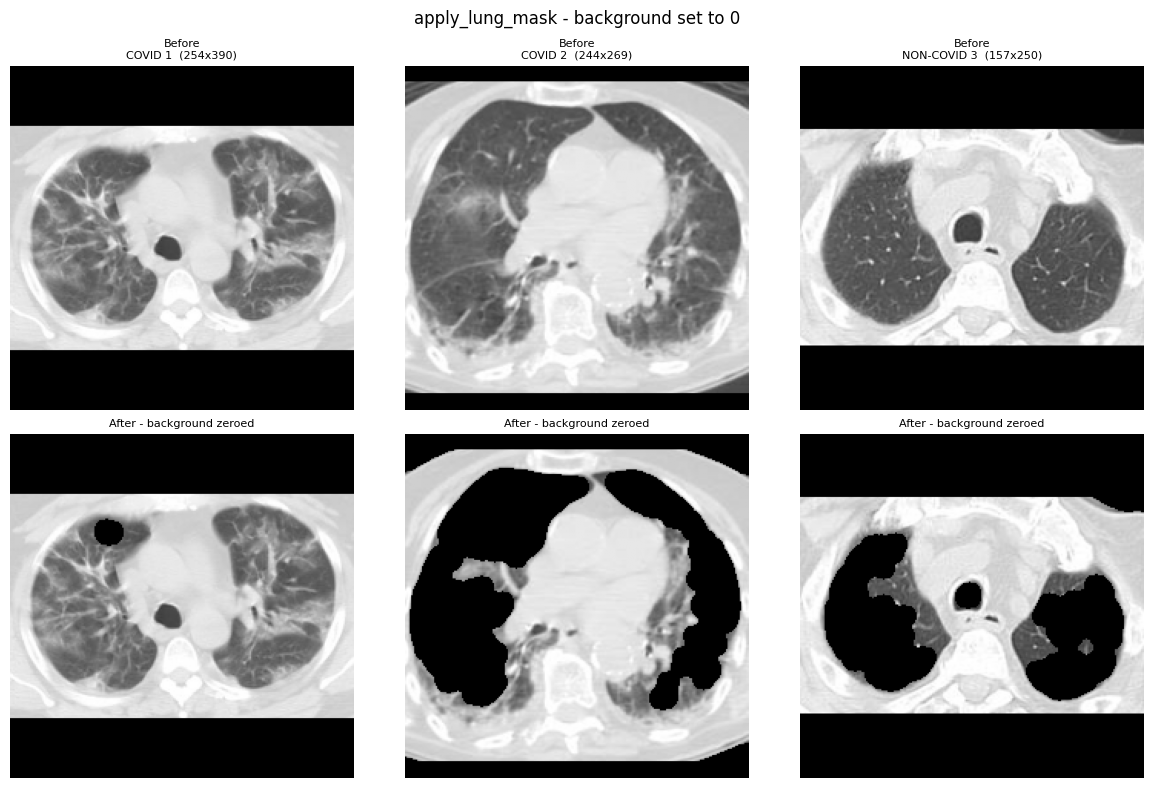

In [6]:
masked = [apply_lung_mask(img, msk) for img, msk in zip(resized, masks)]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for col, (orig, mskd, title) in enumerate(zip(resized, masked, sample_titles)):
    axes[0, col].imshow(orig, cmap='gray')
    axes[0, col].set_title(f'Before\n{title}', fontsize=8)
    axes[0, col].axis('off')
    axes[1, col].imshow(mskd, cmap='gray')
    axes[1, col].set_title('After - background zeroed', fontsize=8)
    axes[1, col].axis('off')
fig.suptitle('apply_lung_mask - background set to 0')
plt.tight_layout()
plt.savefig(ROOT / 'docs/figures/demo_05_applymask.png', dpi=120, bbox_inches='tight')
plt.show()


## 6. `build_three_channel` - composite 3 canali per backbone deep

Step finale: combiniamo
- canale 0: grayscale originale,
- canale 1: CLAHE clip=2.0,
- canale 2: CLAHE clip=4.0,

in un'immagine pseudo-RGB. Il backbone pre-addestrato su ImageNet si
aspetta 3 canali; questo composite gli fornisce 3 "viste" complementari
della stessa slice anziche' triplicare lo stesso canale.


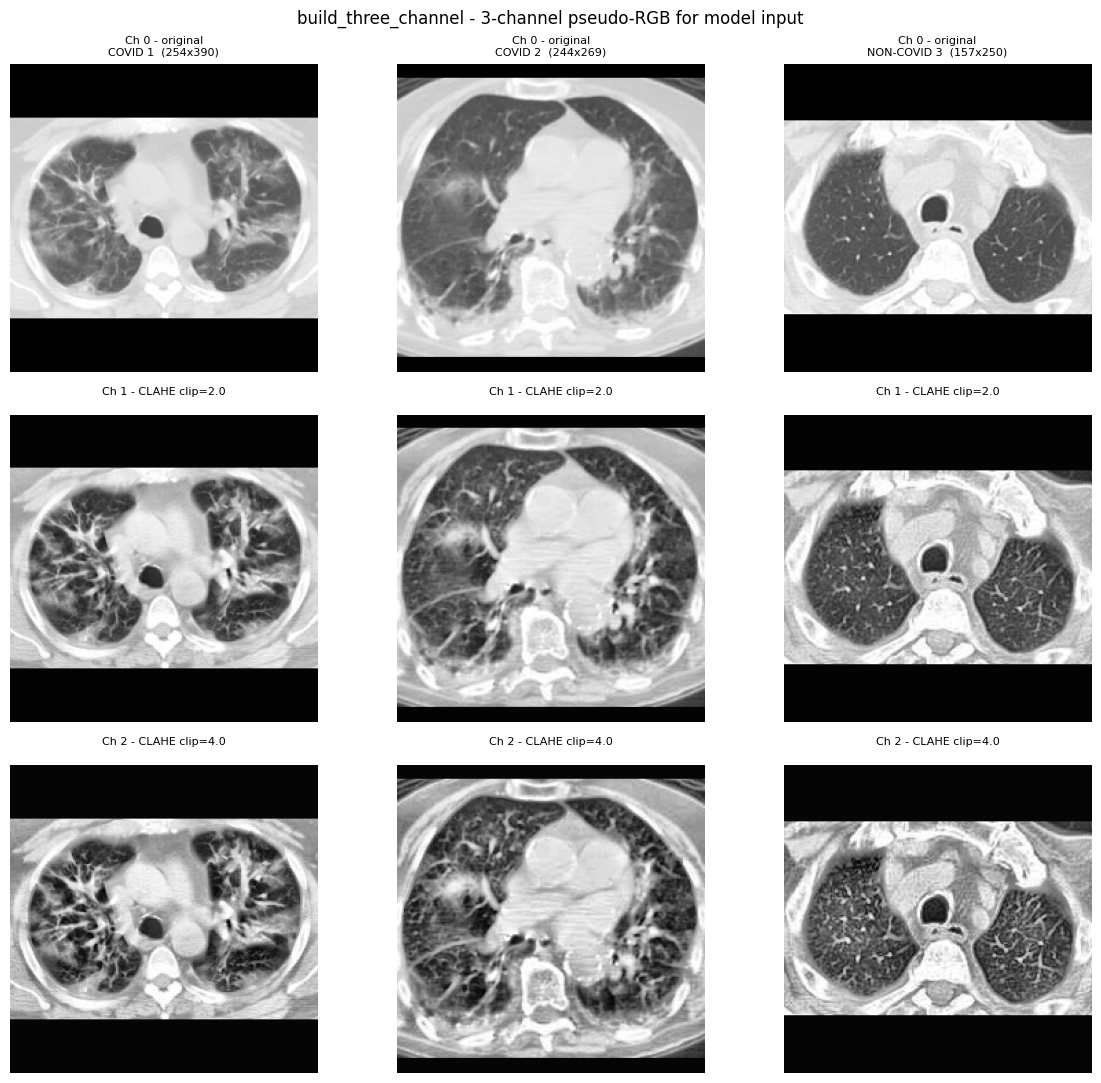

In [7]:
three_ch = [build_three_channel(img) for img in resized]

# Layout 3x3: un canale per riga, un sample per colonna.
chan_labels = ['Ch 0 - original', 'Ch 1 - CLAHE clip=2.0', 'Ch 2 - CLAHE clip=4.0']
fig, axes = plt.subplots(3, 3, figsize=(12, 11))
for col, (tc, title) in enumerate(zip(three_ch, sample_titles)):
    for row in range(3):
        # Visualizziamo ciascun canale separatamente per chiarezza
        # didattica (visualizzare i 3 canali come RGB darebbe colori
        # "fake" non intuitivi).
        axes[row, col].imshow(tc[:, :, row], cmap='gray', vmin=0, vmax=255)
        axes[row, col].set_title(
            f'{chan_labels[row]}\n{title if row == 0 else ""}', fontsize=8
        )
        axes[row, col].axis('off')
fig.suptitle('build_three_channel - 3-channel pseudo-RGB for model input')
plt.tight_layout()
plt.savefig(ROOT / 'docs/figures/demo_06_threechan.png', dpi=120, bbox_inches='tight')
plt.show()
